In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

# 3D halo power spectrum

In [6]:
odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_all.pickle", "rb") as f:
    Pk_mean_gal_all = pickle.load(f)
    Pk_gal_all = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'ps_data/snap40/mvir/ps-intensity-gal_all.pickle'

In [7]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [19]:

#odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [5]:

#odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-cent_logM10.pickle", "rb") as f:
    Pk_mean_cent10 = pickle.load(f)
    Pk_cent10 = pickle.load(f)

In [7]:

#odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sat_logM10.pickle", "rb") as f:
    Pk_mean_sat10 = pickle.load(f)
    Pk_sat10 = pickle.load(f)

In [3]:
sfr_lim = 1

In [35]:
group = False
if group is True:
    group_dir = "group"
else:
    group_dir = "gal"

In [36]:
with open(f"{odir}/snap40/mvir/gal_survey/logSFR{sfr_lim}/{group_dir}/logMmin10.pickle", "rb") as f:
    Pk_mean1 = pickle.load(f)
    Pk1 = pickle.load(f)
    
print(Pk1.attrs["shotnoise"])

338.99130400566617


In [44]:
group_dir = "group"
with open(f"{odir}/snap40/mvir/gal_survey/logSFR{sfr_lim}/{group_dir}/logMmin10.pickle", "rb") as f:
    Pk_mean2 = pickle.load(f)
    Pk2 = pickle.load(f)
print(Pk2.attrs["shotnoise"])

569.7252135315185


In [43]:
print(Pk_mean2)

1.1483551998239317e+98


In [43]:
sfr_lim = 1.5
with open(f"{odir}/snap40/mvir/gal_survey/logSFR{sfr_lim}/{group_dir}/logMmin10.pickle", "rb") as f:
    Pk_mean2 = pickle.load(f)
    Pk2 = pickle.load(f)

In [47]:
sfr_lim = 1.5
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean3 = pickle.load(f)
    Pk3 = pickle.load(f)

shotnoise:  329.67721567426906


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1487: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


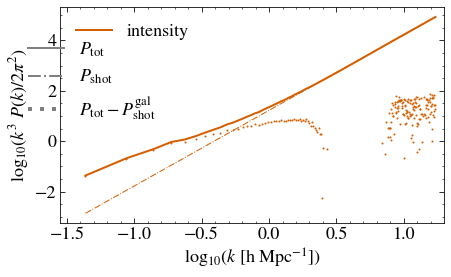

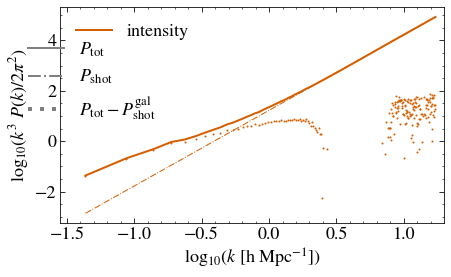

In [12]:
ps.compare_ps_plot([Pk2], labels=["intensity", f"number weighted, logSFR > {sfr_lim}"], shotnoise_subtracted_ps=True)
#plt.ylim(0.4,0.7)

shotnoise:  130.52360745197086
shotnoise:  338.99130400566617


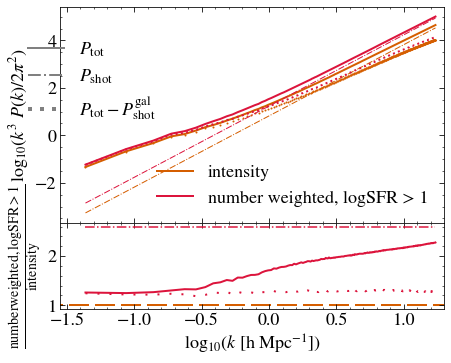

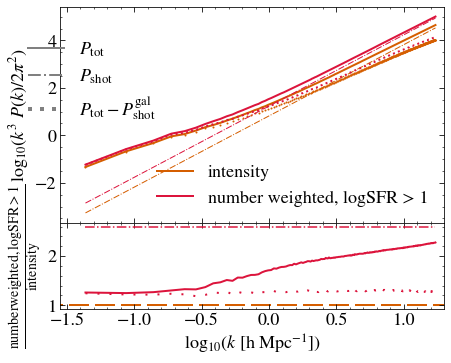

In [10]:
ps.compare_ps_plot([Pk_gal10, Pk1], labels=["intensity", f"number weighted, logSFR > {sfr_lim}"], shotnoise_subtracted_ps=True)
#plt.ylim(0.4,0.7)

In [16]:
iend = 600

In [75]:
tot = Pk_gal10["power"][:iend]
halo2 = (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])
halo1 = (tot -halo2)

In [76]:
shot_gal = Pk_gal10.attrs["shotnoise"]
shot_halo = Pk_sum10.attrs["shotnoise"]

In [77]:
uk = (halo1 - shot_gal)/(shot_halo - shot_gal)

In [73]:
tot_euc = Pk1["power"][:iend]
halo2_euc = Pk2["power"][:iend]-Pk2.attrs["shotnoise"]
halo1_euc = (tot -(halo2))
shot_gal = Pk1.attrs["shotnoise"]
shot_halo = Pk2.attrs["shotnoise"]
print(shot_halo)
print(shot_gal)
uk_gal = (halo1_euc - shot_gal)/(shot_halo - shot_gal)

569.7252135315185
338.99130400566617


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

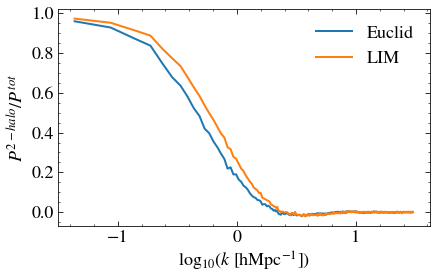

In [86]:
plt.plot(np.log10(Pk1["k"][:iend]), halo2_euc/tot_euc, label = "Euclid")
plt.plot(np.log10(Pk1["k"][:iend]), halo2/tot, label="LIM")
plt.legend()
plt.ylabel("$P^{2-halo}/P^{tot}$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


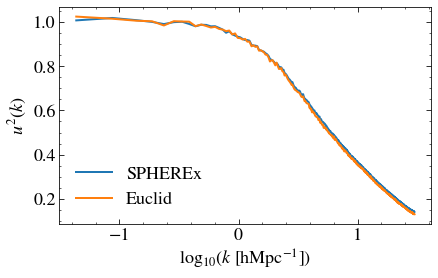

In [66]:
plt.plot(np.log10(Pk1["k"][:iend]), uk, label="SPHEREx")
plt.plot(np.log10(Pk1["k"][:iend]), uk_gal, label="Euclid")
plt.ylabel("$u^2(k)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.legend()

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

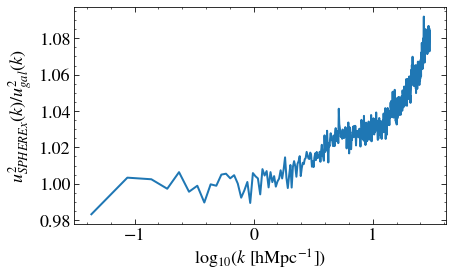

In [64]:
#plt.plot(np.log10(Pk1["k"][:iend]), uk)
plt.plot(np.log10(Pk1["k"][:iend]), uk/uk_gal)
plt.ylabel("$u_{SPHEREx}^2(k)/u_{gal}^2(k)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

In [48]:
ks = Pk_gal10["k"]

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


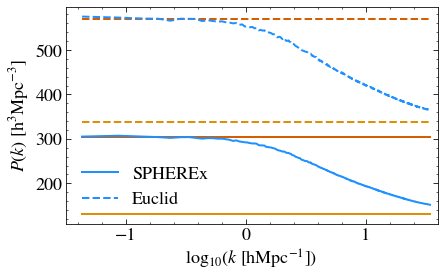

In [55]:
plt.plot(np.log10(ks), [Pk_gal10.attrs["shotnoise"]]*len(ks), c=palette_tab10[1])
plt.plot(np.log10(ks), [Pk_sum10.attrs["shotnoise"]]*len(ks), c=palette_tab10[3])
plt.plot(np.log10(ks), (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"])),c="DodgerBlue", label="SPHEREx")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

plt.plot(np.log10(ks), [Pk1.attrs["shotnoise"]]*len(ks), c=palette_tab10[1], linestyle = "dashed")
plt.plot(np.log10(ks), [Pk2.attrs["shotnoise"]]*len(ks), c=palette_tab10[3], linestyle = "dashed")
plt.plot(np.log10(ks), (Pk1["power"]-(Pk2["power"]-Pk2.attrs["shotnoise"])),c="DodgerBlue", linestyle="dashed", label="Euclid")


plt.ylabel(r"$ P(k)\ [\mathrm{h^3 Mpc^{-3}}]$")
plt.xlim(-1.5, 1.6)
plt.legend()
#plt.savefig("../figures/shotnoise_transition.pdf", format="pdf", bbox_inches="tight")

shotnoise:  250.3269186579436
shotnoise:  253.430388613624


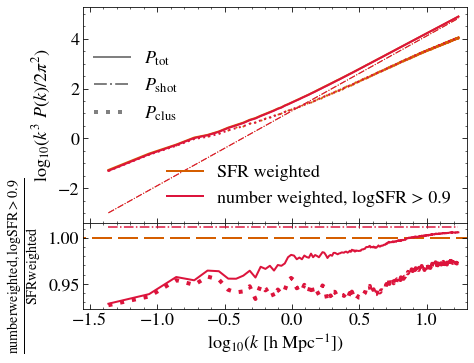

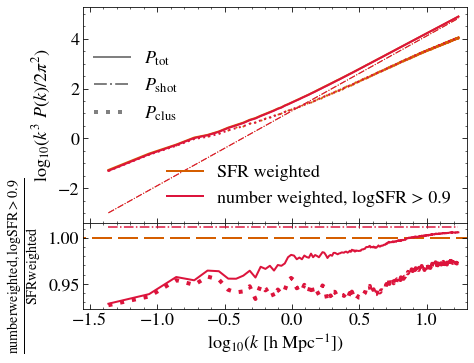

In [67]:
ps.compare_ps_plot([Pk1, Pk2], labels=["SFR weighted", f"number weighted, logSFR > {sfr_lim}"], shotnoise_subtracted_ps=True)
#plt.ylim(0.4,0.7)

In [43]:
importlib.reload(ps)

<module 'MyHaloPS' from '/cosma/home/dp004/dc-zhan5/MyHaloPS.py'>

In [9]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

shotnoise:  130.5236074519707
shotnoise:  202.34259177562294
shotnoise:  352.60039701132393


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1467: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


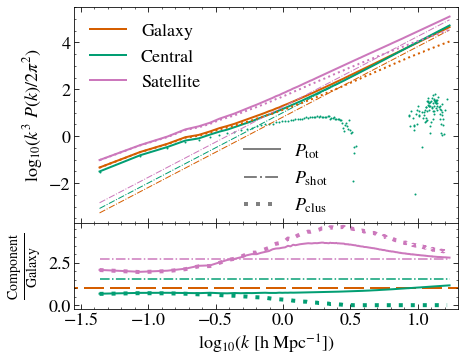

In [34]:
ps.compare_ps_plot([Pk_gal10, Pk_cent10, Pk_sat10], labels=["Galaxy", "Central", "Satellite"], ratio_ylabel_list=["Galaxy","Component"], bbox_to_anchor_grey=(0.4,0.45), bbox_to_anchor_color=(0,1), shotnoise_subtracted_ps=True, dots4group=True, color_list=palette_tab10[3:4] + palette_tab10[2:3] + palette_tab10[4:5])
#plt.savefig("../figures/gal_cent_sat_ps.pdf", format="pdf", bbox_inches="tight")
#plt.ylim(0.5,1.1)

In [313]:

odir = "../ps_data"
with open(f"{odir}/snap99/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 129.69838602072508


In [314]:

#odir = "ps_data"
with open(f"{odir}/snap99/mvir/ps-intensity-cent_logM10.pickle", "rb") as f:
    Pk_mean_cent10 = pickle.load(f)
    Pk_cent10 = pickle.load(f)

In [315]:
Pk_cent10["power"].real[0]/Pk_gal10["power"].real[0]

0.6912655831079177

shotnoise:  129.69838602072508
shotnoise:  193.61219752431288


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1467: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


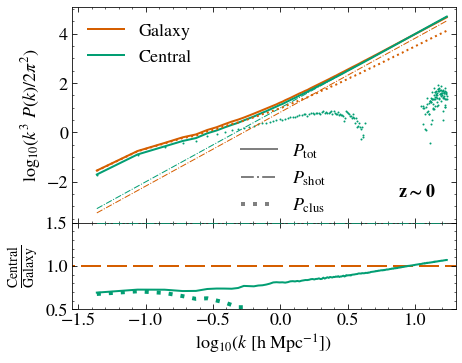

In [319]:
ps.compare_ps_plot([Pk_gal10, Pk_cent10], labels=["Galaxy", "Central", "Satellite"], ratio_ylabel_list=["Galaxy","Central"], bbox_to_anchor_grey=(0.4,0.45), bbox_to_anchor_color=(0,1), shotnoise_subtracted_ps=True, dots4group=True, color_list=palette_tab10[3:4] + palette_tab10[2:3] + palette_tab10[4:5])

plt.ylim(0.5,1.5)
ax=plt.gca()
ax.annotate("$\mathbf{z \sim 0}$", (0.95,1.3), xycoords="axes fraction", ha="right", weight="bold")
#plt.savefig("../figures/gal_cent_ps_snap99.pdf", format="pdf", bbox_inches="tight")

In [42]:
Pk_cent10["power"][0]/Pk_gal10["power"][0]

(0.6785003412071017+0j)

In [211]:
importlib.reload(ps)

<module 'MyHaloPS' from '/cosma/home/dp004/dc-zhan5/MyHaloPS.py'>

shotnoise:  130.5236074519707
shotnoise:  304.09038791547044


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1467: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


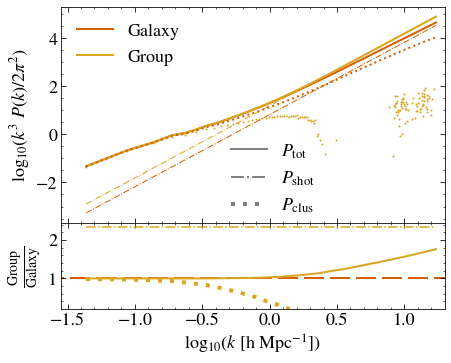

In [262]:
ps.compare_ps_plot([Pk_gal10, Pk_sum10], labels=["Galaxy", "Group"], ratio_ylabel_list=["Galaxy","Group"], bbox_to_anchor_grey=(0.4,0.45), bbox_to_anchor_color=(0,1), shotnoise_subtracted_ps=True, dots4group=True)
plt.ylim(0.2,2.45)
#plt.savefig("../figures/gal_vs_group_ps.pdf", format="pdf", bbox_inches="tight")


In [244]:
(Pk_sum10["power"].real/Pk_gal10["power"].real)[:15]

array([0.99989444, 0.99951578, 0.99961387, 1.00000303, 1.00101271,
       1.00014799, 0.99990835, 1.00172576, 1.00425329, 1.00308447,
       1.00363478, 1.00583237, 1.00604923, 1.00894536, 1.01221548])

In [248]:
((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/(Pk_gal10["power"].real-Pk_gal10.attrs["shotnoise"]))[:15]


array([0.98423584, 0.97174307, 0.94866457, 0.93208679, 0.89042163,
       0.85658295, 0.82858145, 0.78780759, 0.74824936, 0.71176636,
       0.67149332, 0.6363229 , 0.60494576, 0.57128228, 0.53738091])

In [246]:
np.log10(ks[:15])

array([-1.36238137, -1.06033514, -0.85899556, -0.72547219, -0.62661139,
       -0.54272912, -0.473019  , -0.41424163, -0.36117288, -0.31354678,
       -0.27102314, -0.23226579, -0.19665425, -0.16393475, -0.13327703])

In [6]:
ks = Pk_gal10["k"]
coef = ks**3 / (2 * np.pi **2)

In [10]:
color_list1 = palette_tab10[3:4] + palette_tab10[1:2]

In [11]:
color_list1 = palette_tab10[3:4] + ["goldenrod"]

In [15]:
color_list2 = ["DodgerBlue", "purple"]

In [13]:
len_k = 344

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log10
  """Entry point for launching an IPython kernel.


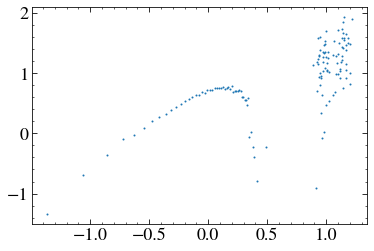

In [102]:
plt.scatter(np.log10(ks)[:len_k], np.log10((coef*Pk_sum10["power"].real)- (coef*Pk_sum10.attrs["shotnoise"].real))[:len_k], s=1)
#plt.ylim(0,10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in log10
  from ipykernel import kernelapp as app
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in log10
  app.launch_new_instance()


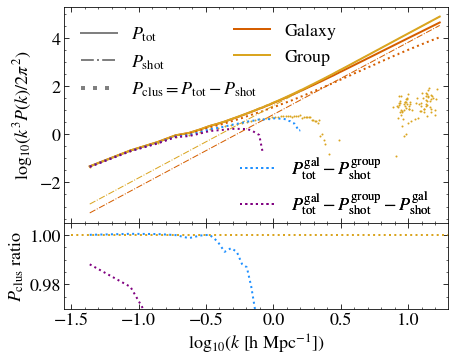

In [276]:
#fig,ax = plt.subplots()
figsize = (2*10/3,2*3)
fig1 = plt.figure(figsize=figsize)
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_gal10["power"].real)[:len_k], label="TNG total", color=color_list1[0])
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_sum10["power"].real)[:len_k], label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks[:len_k]), np.log10(coef * (Pk_gal10["power"].real-Pk_gal10.attrs["shotnoise"]))[:len_k], linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
plt.scatter(np.log10(ks[:len_k]), np.log10(coef * (Pk_sum10["power"].real- Pk_sum10.attrs["shotnoise"]))[:len_k], label="TNG clustering (group)", color=color_list1[1], s=1)

plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_gal10.attrs["shotnoise"])[:len_k], linestyle="dashdot", label="TNG shot noise", color=color_list1[0], linewidth=1)
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_sum10.attrs["shotnoise"])[:len_k], linestyle="dashdot", label="TNG shot noise", color=color_list1[1], linewidth=1)



plt.plot(np.log10(ks[:len_k]), np.log10(coef *(Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"]))[:len_k], label="Subtract shotnoise", color = color_list2[0], linestyle="dotted")
plt.plot(np.log10(ks[:len_k]), np.log10(coef *(Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"] - Pk_gal10.attrs["shotnoise"]))[:len_k], label="Subtract shotnoise", color = color_list2[1], linestyle="dotted")

#plt.plot(np.log10(ks), np.log10(normed_Pk_matter_nl), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
#plt.xlim(-1.5, 0.5)

label_list = ["Galaxy", "Group"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list1[i], linestyle="solid", label=label)
    solid_lines.append(solid_line)

first_legend = ax.legend(handles=solid_lines, frameon=False, loc="upper left", bbox_to_anchor=(0.4,1))
ax.add_artist(first_legend)


color="grey"
total_ps_leg = Line2D([],[],color=color, linestyle="solid", label=r"$P_\mathrm{tot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color,linestyle=(0, (1, 2)), label=r"$P_{\mathrm{clus}} = P_{\rm tot} - P_{\rm shot}$", linewidth=4)
shot_ps_leg = Line2D([],[],color=color, label=r"$P_{\mathrm{shot}}$", linewidth=2, linestyle="dashdot")

leg_list = [total_ps_leg, shot_ps_leg, shotnoise_subtracted_ps_leg]
leg = ax.legend(handles=leg_list,bbox_to_anchor=(0,0.5), loc="lower left", frameon=False)
ax.add_artist(leg)
plt.xlim(-1.55,1.3)
plt.xticks(color="w")

label_list = [r"$P_{\rm tot}^{\rm gal} - P_{\rm shot}^{\rm group}$", r"$P_{\rm tot}^{\rm gal} - P_{\rm shot}^{\rm group} -  P_{\rm shot}^{\rm gal}$"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list2[i], linestyle="dotted", label=label)
    solid_lines.append(solid_line)
second_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right", bbox_to_anchor = (1,-0.05))
ax.add_artist(second_legend)

frame2 = fig1.add_axes((.15,.1,.8,.2))

linewidth1=1
plt.plot([-1.5,np.log10(ks[-1])],[1,1],  color=color_list1[1], linestyle="dotted")

#plt.plot(np.log10(ks[:len_k]), (Pk_gal10["power"].real/Pk_gal10["power"].real)[:len_k])
iend = 15
plt.plot(np.log10(ks[:iend]), (Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"])[:iend]/(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])[:iend], linestyle="dotted", color=color_list2[0])
plt.plot(np.log10(ks[:iend]), (Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"] - Pk_gal10.attrs["shotnoise"])[:iend]/(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])[:iend], linestyle="dotted", color=color_list2[1])

#plt.plot(np.log10(ks), coef * Pk_gal10["power"]/(pkgal2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), coef * Pk_sum10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[1])
#plt.plot(np.log10(ks),coef * (Pk_gal10["power"]-Pk_gal10.attrs["shotnoise"])/(pkgal2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
#plt.plot(np.log10(ks), normed_Pk_matter_nl/normed_Pk_matter_lin, label="nonlinear x 4", color = color_list2[1], linestyle="dotted")




plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
#plt.ylim(0.9,2.5)
#plt.ylabel(r"$\rm \dfrac{gal - group}{group - group}$", fontsize=16)
plt.ylabel(r"$P_{\mathrm{clus}}$ ratio")
#plt.savefig("figures/tng_vs_matter.pdf", format="pdf", bbox_inches="tight")
plt.xlim(-1.55,1.3)
plt.ylim(0.97, 1.005)
#plt.savefig("../figures/one_halo_term.pdf", format="pdf", bbox_inches="tight")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in log10
  from ipykernel import kernelapp as app
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in log10
  app.launch_new_instance()


(0.97, 1.03)

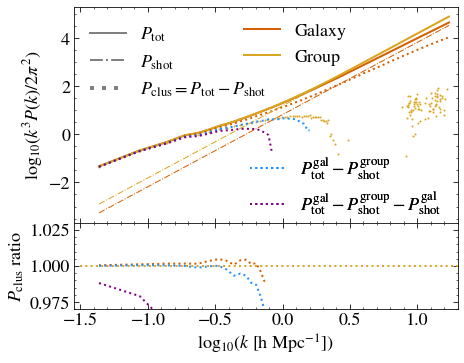

In [27]:
#fig,ax = plt.subplots()
figsize = (2*10/3,2*3)
fig1 = plt.figure(figsize=figsize)
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_gal10["power"].real)[:len_k], label="TNG total", color=color_list1[0])
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_sum10["power"].real)[:len_k], label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks[:len_k]), np.log10(coef * (Pk_gal10["power"].real-Pk_gal10.attrs["shotnoise"]))[:len_k], linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
plt.scatter(np.log10(ks[:len_k]), np.log10(coef * (Pk_sum10["power"].real- Pk_sum10.attrs["shotnoise"]))[:len_k], label="TNG clustering (group)", color=color_list1[1], s=1)

plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_gal10.attrs["shotnoise"])[:len_k], linestyle="dashdot", label="TNG shot noise", color=color_list1[0], linewidth=1)
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_sum10.attrs["shotnoise"])[:len_k], linestyle="dashdot", label="TNG shot noise", color=color_list1[1], linewidth=1)



plt.plot(np.log10(ks[:len_k]), np.log10(coef *(Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"]))[:len_k], label="Subtract shotnoise", color = color_list2[0], linestyle="dotted")
plt.plot(np.log10(ks[:len_k]), np.log10(coef *(Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"] - Pk_gal10.attrs["shotnoise"]))[:len_k], label="Subtract shotnoise", color = color_list2[1], linestyle="dotted")

#plt.plot(np.log10(ks), np.log10(normed_Pk_matter_nl), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
#plt.xlim(-1.5, 0.5)

label_list = ["Galaxy", "Group"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list1[i], linestyle="solid", label=label)
    solid_lines.append(solid_line)

first_legend = ax.legend(handles=solid_lines, frameon=False, loc="upper left", bbox_to_anchor=(0.4,1))
ax.add_artist(first_legend)


color="grey"
total_ps_leg = Line2D([],[],color=color, linestyle="solid", label=r"$P_\mathrm{tot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color,linestyle=(0, (1, 2)), label=r"$P_{\mathrm{clus}} = P_{\rm tot} - P_{\rm shot}$", linewidth=4)
shot_ps_leg = Line2D([],[],color=color, label=r"$P_{\mathrm{shot}}$", linewidth=2, linestyle="dashdot")

leg_list = [total_ps_leg, shot_ps_leg, shotnoise_subtracted_ps_leg]
leg = ax.legend(handles=leg_list,bbox_to_anchor=(0,0.5), loc="lower left", frameon=False)
ax.add_artist(leg)
plt.xlim(-1.55,1.3)
plt.xticks(color="w")

label_list = [r"$P_{\rm tot}^{\rm gal} - P_{\rm shot}^{\rm group}$", r"$P_{\rm tot}^{\rm gal} - P_{\rm shot}^{\rm group} -  P_{\rm shot}^{\rm gal}$"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list2[i], linestyle="dotted", label=label)
    solid_lines.append(solid_line)
second_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right", bbox_to_anchor = (1,-0.05))
ax.add_artist(second_legend)

frame2 = fig1.add_axes((.15,.1,.8,.2))

linewidth1=1
plt.plot([-1.5,np.log10(ks[-1])],[1,1],  color=color_list1[1], linestyle="dotted")

#plt.plot(np.log10(ks[:len_k]), (Pk_gal10["power"].real/Pk_gal10["power"].real)[:len_k])
iend = 15
plt.plot(np.log10(ks[:iend]), (Pk_gal10["power"].real - Pk_gal10.attrs["shotnoise"])[:iend]/(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])[:iend], linestyle="dotted", color=color_list1[0])

plt.plot(np.log10(ks[:iend]), (Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"])[:iend]/(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])[:iend], linestyle="dotted", color=color_list2[0])
plt.plot(np.log10(ks[:iend]), (Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"] - Pk_gal10.attrs["shotnoise"])[:iend]/(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])[:iend], linestyle="dotted", color=color_list2[1])

#plt.plot(np.log10(ks), coef * Pk_gal10["power"]/(pkgal2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), coef * Pk_sum10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[1])
#plt.plot(np.log10(ks),coef * (Pk_gal10["power"]-Pk_gal10.attrs["shotnoise"])/(pkgal2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
#plt.plot(np.log10(ks), normed_Pk_matter_nl/normed_Pk_matter_lin, label="nonlinear x 4", color = color_list2[1], linestyle="dotted")




plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
#plt.ylim(0.9,2.5)
#plt.ylabel(r"$\rm \dfrac{gal - group}{group - group}$", fontsize=16)
plt.ylabel(r"$P_{\mathrm{clus}}$ ratio")
#plt.savefig("figures/tng_vs_matter.pdf", format="pdf", bbox_inches="tight")
plt.xlim(-1.55,1.3)
plt.ylim(0.97, 1.03)
#plt.savefig("../figures/one_halo_term_w_gal.pdf", format="pdf", bbox_inches="tight")

In [115]:
(Pk_sum10["power"].real - Pk_sum10.attrs["shotnoise"])[:50]

array([ 1.09105623e+04,  6.07516208e+03,  3.23271302e+03,  2.38203614e+03,
        1.39640487e+03,  1.03547358e+03,  8.39471954e+02,  6.38373875e+02,
        5.05679099e+02,  4.23085416e+02,  3.49942348e+02,  2.97584008e+02,
        2.60583236e+02,  2.25032943e+02,  1.94624979e+02,  1.76998914e+02,
        1.43605951e+02,  1.36291570e+02,  1.13095468e+02,  1.07199429e+02,
        9.35239218e+01,  8.17106140e+01,  7.56872165e+01,  6.58389754e+01,
        5.88274447e+01,  5.19544131e+01,  4.75593726e+01,  4.02997823e+01,
        3.77400285e+01,  3.46954303e+01,  3.00649892e+01,  3.01919876e+01,
        2.20117830e+01,  2.07277939e+01,  1.92102542e+01,  1.77245029e+01,
        1.66300962e+01,  1.50236227e+01,  1.08172475e+01,  1.00821172e+01,
        8.48061643e+00,  7.68513646e+00,  6.04649444e+00,  7.26682418e+00,
        1.52410982e+00,  1.74547792e+00, -1.26108846e-01,  8.77374653e-01,
        5.48523362e-01, -2.42973241e-01])

In [116]:
(Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"])[:50]

array([ 1.09117462e+04,  6.07825254e+03,  3.23407921e+03,  2.38202801e+03,
        1.39468450e+03,  1.03527538e+03,  8.39576769e+02,  6.36750213e+02,
        5.02249500e+02,  4.20849364e+02,  3.47573695e+02,  2.94095169e+02,
        2.57187933e+02,  2.20341711e+02,  1.88606450e+02,  1.68466056e+02,
        1.36207546e+02,  1.26586004e+02,  1.02335787e+02,  9.55569656e+01,
        8.13808663e+01,  6.83030327e+01,  6.14213134e+01,  5.15825244e+01,
        4.40759370e+01,  3.38847134e+01,  2.89280457e+01,  2.16763754e+01,
        1.87324871e+01,  1.27407072e+01,  7.63495978e+00,  7.33355585e+00,
       -1.44645270e+00, -3.86546321e+00, -6.18394861e+00, -8.95451019e+00,
       -1.23563093e+01, -1.46855818e+01, -1.95842066e+01, -2.12668189e+01,
       -2.41772818e+01, -2.45796901e+01, -2.73250520e+01, -2.80052386e+01,
       -3.39222236e+01, -3.39050718e+01, -3.74235465e+01, -3.66751551e+01,
       -3.95084548e+01, -4.09851224e+01])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log10
  


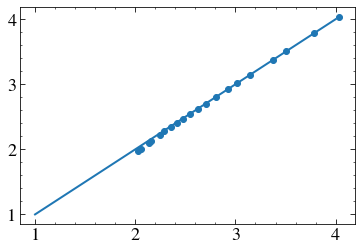

In [126]:
iend = 20
plt.scatter(np.log10((Pk_sum10["power"].real - Pk_sum10.attrs["shotnoise"]))[:iend], np.log10((Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"]))[:iend])
plt.plot([1,4], [1,4])

In [129]:
np.log10(Pk_gal10["k"][20])

0.015175432330778428

In [223]:
p1 = Pk_gal10["power"].real - (Pk_sum10["power"].real- Pk_sum10.attrs["shotnoise"]) - Pk_gal10.attrs["shotnoise"]

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in log10
  from ipykernel import kernelapp as app


(0.97, 1.005)

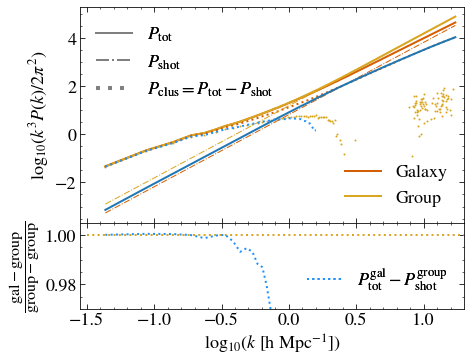

In [249]:
#fig,ax = plt.subplots()
figsize = (2*10/3,2*3)
fig1 = plt.figure(figsize=figsize)
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_gal10["power"].real)[:len_k], label="TNG total", color=color_list1[0])
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_sum10["power"].real)[:len_k], label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks[:len_k]), np.log10(coef * (Pk_gal10["power"].real-Pk_gal10.attrs["shotnoise"]))[:len_k], linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
plt.scatter(np.log10(ks[:len_k]), np.log10(coef * (Pk_sum10["power"].real- Pk_sum10.attrs["shotnoise"]))[:len_k], label="TNG clustering (group)", color=color_list1[1], s=1)

plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_gal10.attrs["shotnoise"])[:len_k], linestyle="dashdot", label="TNG shot noise", color=color_list1[0], linewidth=1)
plt.plot(np.log10(ks[:len_k]), np.log10(coef * Pk_sum10.attrs["shotnoise"])[:len_k], linestyle="dashdot", label="TNG shot noise", color=color_list1[1], linewidth=1)

plt.plot(np.log10(ks[:len_k]), np.log10(coef* p1)[:len_k])

plt.plot(np.log10(ks[:len_k]), np.log10(coef *(Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"]))[:len_k], label="Subtract shotnoise", color = color_list2[0], linestyle="dotted")
#plt.plot(np.log10(ks), np.log10(normed_Pk_matter_nl), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
#plt.xlim(-1.5, 0.5)

label_list = ["Galaxy", "Group"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list1[i], linestyle="solid", label=label)
    solid_lines.append(solid_line)

first_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right")
ax.add_artist(first_legend)


color="grey"
total_ps_leg = Line2D([],[],color=color, linestyle="solid", label=r"$P_\mathrm{tot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color,linestyle=(0, (1, 2)), label=r"$P_{\mathrm{clus}} = P_{\rm tot} - P_{\rm shot}$", linewidth=4)
shot_ps_leg = Line2D([],[],color=color, label=r"$P_{\mathrm{shot}}$", linewidth=2, linestyle="dashdot")

leg_list = [total_ps_leg, shot_ps_leg, shotnoise_subtracted_ps_leg]
leg = ax.legend(handles=leg_list,bbox_to_anchor=(0,0.5), loc="lower left", frameon=False)
ax.add_artist(leg)
plt.xlim(-1.55,1.3)
plt.xticks(color="w")
frame2 = fig1.add_axes((.15,.1,.8,.2))

linewidth1=1
plt.plot([-1.5,np.log10(ks[-1])],[1,1],  color=color_list1[1], linestyle="dotted")

#plt.plot(np.log10(ks[:len_k]), (Pk_gal10["power"].real/Pk_gal10["power"].real)[:len_k])
iend = 15
plt.plot(np.log10(ks[:iend]), (Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"])[:iend]/(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])[:iend], linestyle="dotted", color=color_list2[0])
#plt.plot(np.log10(ks), coef * Pk_gal10["power"]/(pkgal2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), coef * Pk_sum10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[1])
#plt.plot(np.log10(ks),coef * (Pk_gal10["power"]-Pk_gal10.attrs["shotnoise"])/(pkgal2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
#plt.plot(np.log10(ks), normed_Pk_matter_nl/normed_Pk_matter_lin, label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
label_list = [r"$P_{\rm tot}^{\rm gal} - P_{\rm shot}^{\rm group}$"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list2[i], linestyle="dotted", label=label)
    solid_lines.append(solid_line)

ax = plt.gca()
second_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right", bbox_to_anchor = (1,0))
ax.add_artist(second_legend)

plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
#plt.ylim(0.9,2.5)
plt.ylabel(r"$\rm \dfrac{gal - group}{group - group}$", fontsize=16)
#plt.savefig("figures/tng_vs_matter.pdf", format="pdf", bbox_inches="tight")
plt.xlim(-1.55,1.3)
plt.ylim(0.97, 1.005)
#plt.ylim(0.999, 1.005)
#plt.savefig("../figures/one_halo_term.pdf", format="pdf", bbox_inches="tight")

In [250]:
 (Pk_gal10["power"].real - Pk_sum10.attrs["shotnoise"])[:iend]/(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])[:iend]

array([1.00010851, 1.0005087 , 1.00042262, 0.99999659, 0.998768  ,
       0.99980858, 1.00012486, 0.99745657, 0.99321784, 0.99471489,
       0.9932313 , 0.98827612, 0.98697037, 0.97915314, 0.96907627])

In [253]:
np.log10(ks[:iend])

array([-1.36238137, -1.06033514, -0.85899556, -0.72547219, -0.62661139,
       -0.54272912, -0.473019  , -0.41424163, -0.36117288, -0.31354678,
       -0.27102314, -0.23226579, -0.19665425, -0.16393475, -0.13327703])

In [278]:
(1.00010851-1)*100

0.01085100000000061